### Disclaimer

This tutorial assumes that you have already familiarized yourself with the Autoencodix pipeline and thus only briefly touches on topics like data preparation and training your Autoencodix models.
If you are not yet familiar with these topics, the other tutorial notebooks in this repo are a good reference.

---

## Overview

Hyperparameter optimization allows you to systematically search over model parameters such as batch size, learning rate, network depth, and regularization strength. Instead of choosing these values manually, a hyperparameter optimization (HPO) framework like Optuna can be used to sample different configurations, run the model, evaluate it, and use the results to guide future trials.

Each trial follows this workflow:

1. Build a model configuration from sampled hyperparameters.
2. Train the model on the provided dataset.
3. Evaluate the learned embedding on downstream machine-learning tasks or other metrics like reconstruction loss.
4. Report evaluation metrics back to the optimizer.

The optimizer then uses an optimization algorithm to efficiently decide which hyperparameters to try next.

---

# Hyperparameter Optimization with Autoencodix using Optuna

This tutorial explains how to perform hyperparameter optimization (HPO) for Autoencodix models using Optuna. More information and documentation can be found here: https://optuna.org/. The goal is to automatically find good training settings for a chosen architecture by evaluating many different configurations and selecting the one with the best (downstream) performance.

Prerequisites:
 * training data
 * an Autoencodix model, e.g. Vanillix, Ontix, etc.

This tutorial covers all the necessary steps:
  * defining an objective function and the search space
  * running the optimization study
  * visualizing the results
  * and finally retrieving the best configuration

---



## Step 0: Install Optuna

To install Optuna from pip:

```
pip install optuna plotly
```
Note: `plotly` is installed for Optuna's built-in visualizations.


## Step 1: Defining the Objective Function and Configuration Space

### Objective Function

The core of the optimization is the objective function. This function defines what happens in a single trial.
Unlike other frameworks where the search space is defined separately, Optuna defines the configuration space dynamically inside the objective function using the `trial` object.

For each trial proposed by the optimizer, the objective function:

1. Samples hyperparameters like batch size, dropout probability, and learning rate using methods like `trial.suggest_int` or `trial.suggest_float`.
2. Instantiates and trains the model with the sampled configuration on the dataset.
3. Evaluates the learned embedding by computing performance metrics such as downstream performance and reconstruction loss.
4. Returns the metric to be optimized back to Optuna.

We can also store additional metrics that we don't optimize for directly (e.g., tracking reconstruction loss while optimizing for downstream performance) using `trial.set_user_attr`.

---


In [8]:
import optuna

#metric = "downstream_performance"
metric = "reconstruction_loss"

def objective(trial):
	## Fixed params
	epochs = 100
	checkpoint_interval = 25
	loss_reduction = "sum"
	tasks = "condition"

	## Tunable params sampled by Optuna
	batch_size = trial.suggest_int("batch_size", 128, 4096)
	drop_p = trial.suggest_float("drop_p", 0.0, 0.9)
	enc_factor = trial.suggest_int("enc_factor", 1, 5)
	weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-1, log=True)
	beta = trial.suggest_float("beta", 1e-5, 10, log=True)
	learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
	n_layers = trial.suggest_int("n_layers", 2, 5)

	from autoencodix.data.datapackage import DataPackage
	from autoencodix.configs.vanillix_config import VanillixConfig
	import sklearn
	from sklearn import linear_model
	import autoencodix as acx
	from autoencodix.utils.example_data import raw_protein, raw_rna, annotation
	from autoencodix.configs.default_config import DataCase

	# Step 1.1 instantiating our model with a given configuration
    # Our dataset
	my_datapackage = DataPackage(
    	multi_bulk={"rna": raw_rna, "protein": raw_protein},
    	annotation={"paired": annotation},
	)

    # The sampled configuration
	myconfig = VanillixConfig(
			## Fixed params
			data_case=DataCase.MULTI_BULK,
			epochs=epochs,
			checkpoint_interval= checkpoint_interval,
			loss_reduction= loss_reduction,
        	device="cpu",
			## Tunable params
			batch_size= batch_size,
			drop_p= drop_p,
			enc_factor= enc_factor,
			weight_decay= weight_decay,
			beta= beta,
			learning_rate= learning_rate,
			n_layers= n_layers,
			)

	vanillix = acx.Vanillix(data=my_datapackage, config=myconfig)
	vanillix.run()

	# Step 1.2 Evaluating our learned embedding
    # The reconstruction loss is provided directly by autoencodix
	reconstruction_loss = float(vanillix.result.sub_losses.get("recon_loss").get(epoch=-1, split="valid"))

    # Compute the downstream performance
    # We define a list of tasks which are either regression or classification tasks from our annotation file.
    # A linear model is used on the learned embedding to compute the performance for each task.
	sklearn.set_config(enable_metadata_routing=True)

	# Define Classifier
	sklearn_ml_class = linear_model.LogisticRegression(
		solver="sag",
		n_jobs=-1,
		class_weight="balanced",
		max_iter=200,
	)
    # Define Regressor
	sklearn_ml_regression = linear_model.LinearRegression() # Unused, only needed if downstream task is regression variable

    # Downstream performance metrics
	own_metric_class = 'roc_auc_ovo'
	own_metric_regression = 'r2'

	# make sure the task list has the proper type for autoencodix evaluate function
	tasks_list = [t for s in (tasks.split("$") if isinstance(tasks,str) else tasks) for t in (s.split("$") if isinstance(s,str) else [s])]

	vanillix.evaluate(
		ml_model_class=sklearn_ml_class,
		ml_model_regression=sklearn_ml_regression,
		params= tasks_list,
		metric_class = own_metric_class,
		metric_regression = own_metric_regression,
		reference_methods = [], # No reference methods for tuning
		split_type = "use-split",
		n_downsample = None, # Use a subset of the data for faster evaluation
	)

	# here we take the average over all downstream tasks
	downstream_performance = vanillix.result.embedding_evaluation.loc[
		vanillix.result.embedding_evaluation.score_split == "valid",
		"value"
	].mean()

    # Store additional metrics in the trial so we can analyze them later
	trial.set_user_attr("reconstruction_loss", reconstruction_loss)
	trial.set_user_attr("downstream_performance", downstream_performance)

    # Return the target metric for optimization
	if metric == "downstream_performance":
		return downstream_performance
	else:
		return reconstruction_loss



## Step 2: Running the Optimization

Once the objective function is defined, we create a Study. The study coordinates the optimization process by:

* Choosing an optimization algorithm, which Optuna calls a **Sampler** (e.g., TPE, Random, CMA-ES).
* Sampling hyperparameter configurations using the chosen algorithm.
* Launching trials using our objective function.
* Collecting and keeping track of reported metrics.

While Optuna uses the `TPESampler` (Tree-structured Parzen Estimator) by default, we can explicitly specify our chosen algorithm. Below, we instantiate the `TPESampler` explicitly, but we also show how easy it is to swap it for a `RandomSampler`.

We must also specify whether we want to `maximize` or `minimize` our target metric. The optimizer runs for a set number of trials (`n_trials`) or amount of time (`timeout`).

---



In [9]:
import optuna
from optuna.samplers import TPESampler, RandomSampler

# Set optimization direction based on our metric
if metric == "downstream_performance":
    direction = "maximize"
else:
    direction = "minimize"

# Explicitly define the optimization algorithm (Sampler)
sampler = TPESampler(seed=42)
# sampler = RandomSampler(seed=42) # Alternative sampler example

# Create an Optuna study with the chosen sampler
study = optuna.create_study(
    study_name="autoencodix-optimization",
    direction=direction,
    sampler=sampler
)

# Start tuning
# Note: You can also specify timeout=300 to stop after 5 minutes
study.optimize(objective, n_trials=10)


[I 2026-06-04 11:53:11,613] A new study created in memory with name: autoencodix-optimization


in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
anno key: paired
Epoch 1 - Train Loss: 440.2611
Sub-losses: recon_loss: 440.2611
Epoch 1 - Valid Loss: 208.8215
Sub-losses: recon_loss: 208.8215
Epoch 2 - Train Loss: 468.8945
Sub-losses: recon_loss: 468.8945
Epoch 2 - Valid Loss: 206.5045
Sub-losses: recon_loss: 206.5045
Epoch 3 - Train Loss: 462.6298
Sub-losses: recon_loss: 462.6298
Epoch 3 - Valid Loss: 205.1952
Sub-losses: recon_loss: 205.1952
Epoch 4 - Train Loss: 513.0863
Sub-losses: recon_loss: 513.0863
Epoch 4 - Valid Loss: 204.6623
Sub-losses: recon_loss: 204.6623
Epoch 5 - Train Loss: 415.7704
Sub-losses: recon_loss: 415.7704
Epoch 5 - Valid Loss: 204.3896
Sub-losses: recon_loss: 204.3896
Epoch 6 - Train Loss: 397.9467
Sub-losses: recon_loss: 397.9467
Epoch 6 - Valid Loss: 204.2713
Sub-losses: recon_loss: 204.2713
Epoch 7 - Train Loss: 458.6699
Sub-losses: recon_loss: 458.6699
Epoch 7 - Valid Loss: 204.1935
Sub-losses: recon_loss: 204.193

/Users/lucathale-bombien/PycharmProjects/autoencodix_package/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-06-04 11:53:12,938] Trial 0 finished with value: 204.47654296875 and parameters: {'batch_size': 1614, 'drop_p': 0.8556428757689246, 'enc_factor': 4, 'weight_decay': 0.0024810409748678114, 'beta': 8.632008168602535e-05, 'learning_rate': 4.207053950287933e-05, 'n_layers': 2}. Best is trial 0 with value: 204.47654296875.


Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: condition
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
anno key: paired
Epoch 1 - Train Loss: 264.3396
Sub-losses: recon_loss: 264.3396
Epoch 1 - Valid Loss: 206.6972
Sub-losses: recon_loss: 206.6972
Epoch 2 - Train Loss: 224.8875
Sub-losses: recon_loss: 224.8875
Epoch 2 - Valid Loss: 206.5836
Sub-losses: recon_loss: 206.5836
Epoch 3 - Train Loss: 207.4807
Sub-losses: recon_loss: 207.4807
Epoch 3 - Valid Loss: 205.2002
Sub-losses: recon_loss: 205.2002
Epoch 4 - Train Loss: 199.4861
Sub-losses: recon_loss: 199.4861
Epoch 4 - Valid Loss: 202.3622
Sub-losses: recon_loss: 202.3622
Epoch 5 - Train Loss: 190.0995
Sub-losses: recon_loss: 190.0995
Epoch 5 - Valid Loss: 199.5577
Sub-losses: recon_loss: 199.5577
Epoch 6 - Train Loss: 187.2548
Sub-losses: recon_loss: 187.2548
Epoch 6 - Valid Loss: 196.8681
Sub-losses: recon_loss: 196.8681
Epoch 7 - Train Loss: 182.6025


/Users/lucathale-bombien/PycharmProjects/autoencodix_package/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-06-04 11:53:14,009] Trial 1 finished with value: 171.4509765625 and parameters: {'batch_size': 3565, 'drop_p': 0.541003510568888, 'enc_factor': 4, 'weight_decay': 1.2087541473056957e-05, 'beta': 6.5987110720540665, 'learning_rate': 0.02136832907235875, 'n_layers': 2}. Best is trial 1 with value: 171.4509765625.


...

Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: condition
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
anno key: paired
Epoch 1 - Train Loss: 290.0026
Sub-losses: recon_loss: 290.0026
Epoch 1 - Valid Loss: 204.0196
Sub-losses: recon_loss: 204.0196
Epoch 2 - Train Loss: 292.5157
Sub-losses: recon_loss: 292.5157
Epoch 2 - Valid Loss: 204.6547
Sub-losses: recon_loss: 204.6547
Epoch 3 - Train Loss: 289.2335
Sub-losses: recon_loss: 289.2335
Epoch 3 - Valid Loss: 205.2741
Sub-losses: recon_loss: 205.2741
Epoch 4 - Train Loss: 286.6452
Sub-losses: recon_loss: 286.6452
Epoch 4 - Valid Loss: 205.9137
Sub-losses: recon_loss: 205.9137
Epoch 5 - Train Loss: 286.8114
Sub-losses: recon_loss: 286.8114
Epoch 5 - Valid Loss: 206.6702
Sub-losses: recon_loss: 206.6702
Epoch 6 - Train Loss: 283.4090
Sub-losses: recon_loss: 283.4090
Epoch 6 - Valid Loss: 207.4588
Sub-losses: recon_loss: 207.4588
Epoch 7 - Train Loss: 282.3956


[I 2026-06-04 11:53:32,548] Trial 8 finished with value: 201.43568359375 and parameters: {'batch_size': 479, 'drop_p': 0.1763845761772307, 'enc_factor': 1, 'weight_decay': 0.0002001342062287998, 'beta': 0.002148145718198267, 'learning_rate': 0.00012172958098369953, 'n_layers': 5}. Best is trial 4 with value: 157.89654296875.


Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: condition
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
anno key: paired
Epoch 1 - Train Loss: 237.5551
Sub-losses: recon_loss: 237.5551
Epoch 1 - Valid Loss: 203.9961
Sub-losses: recon_loss: 203.9961
Epoch 2 - Train Loss: 239.1859
Sub-losses: recon_loss: 239.1859
Epoch 2 - Valid Loss: 203.9137
Sub-losses: recon_loss: 203.9137
Epoch 3 - Train Loss: 239.2100
Sub-losses: recon_loss: 239.2100
Epoch 3 - Valid Loss: 203.9333
Sub-losses: recon_loss: 203.9333
Epoch 4 - Train Loss: 233.8363
Sub-losses: recon_loss: 233.8363
Epoch 4 - Valid Loss: 204.0301
Sub-losses: recon_loss: 204.0301
Epoch 5 - Train Loss: 230.1998
Sub-losses: recon_loss: 230.1998
Epoch 5 - Valid Loss: 204.1712
Sub-losses: recon_loss: 204.1712
Epoch 6 - Train Loss: 237.7387
Sub-losses: recon_loss: 237.7387
Epoch 6 - Valid Loss: 204.3374
Sub-losses: recon_loss: 204.3374
Epoch 7 - Train Loss: 233.6424


[I 2026-06-04 11:53:35,191] Trial 9 finished with value: 208.4765625 and parameters: {'batch_size': 1543, 'drop_p': 0.2528410587186427, 'enc_factor': 3, 'weight_decay': 3.661819220392426e-05, 'beta': 0.6504020246676563, 'learning_rate': 1.9870215385428627e-05, 'n_layers': 5}. Best is trial 4 with value: 157.89654296875.


Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: condition


## Visualizing the Optimization process

### Best Performance over Time
Optuna provides built-in visualization tools based on Plotly to easily explore our results.

In [10]:
from optuna.visualization import plot_optimization_history

# Plot the optimization history showing the objective value over trials
plot_optimization_history(study)


### Hyperparameter Importances
We can also visualize which hyperparameters had the biggest impact on the objective value.

In [11]:
from optuna.visualization import plot_param_importances

plot_param_importances(study)


### Comparing tuning on Reconstruction Loss vs. Downstream Performance

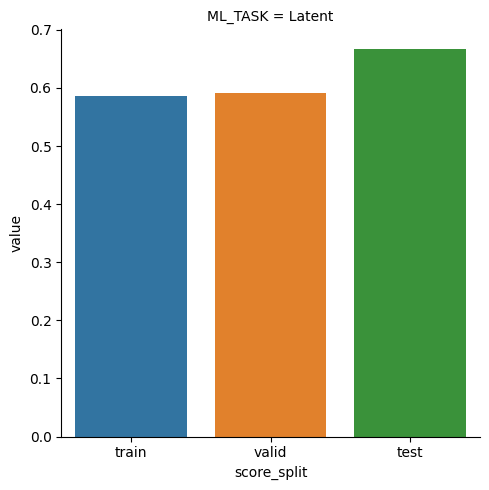

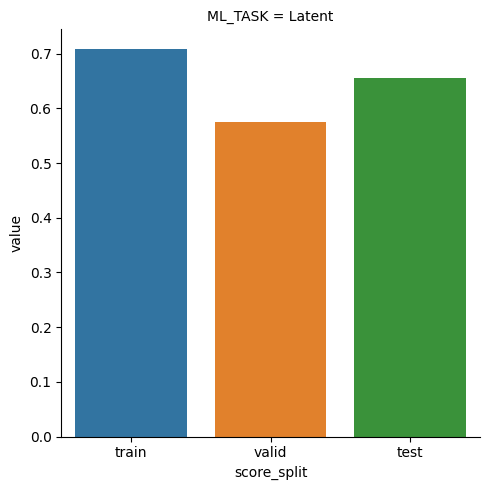

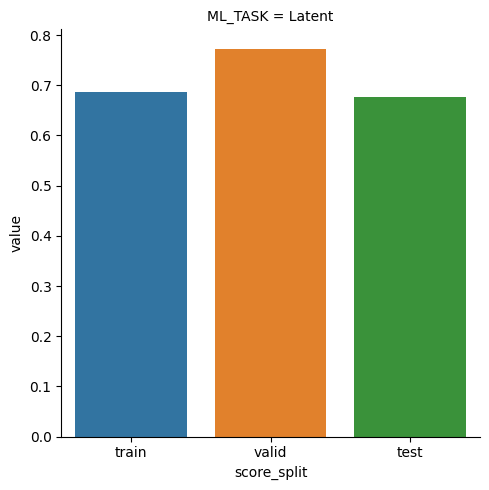

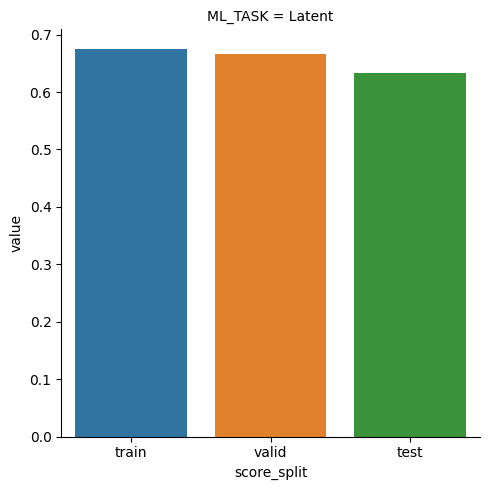

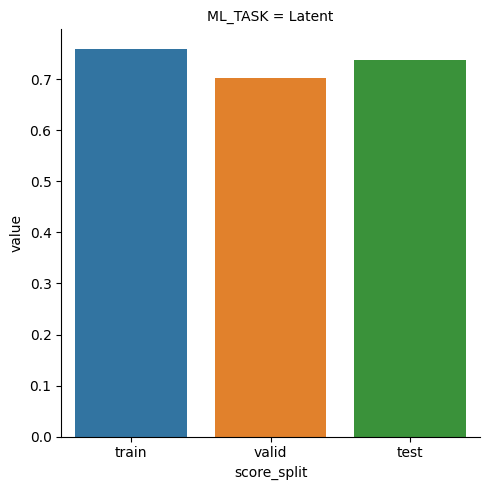

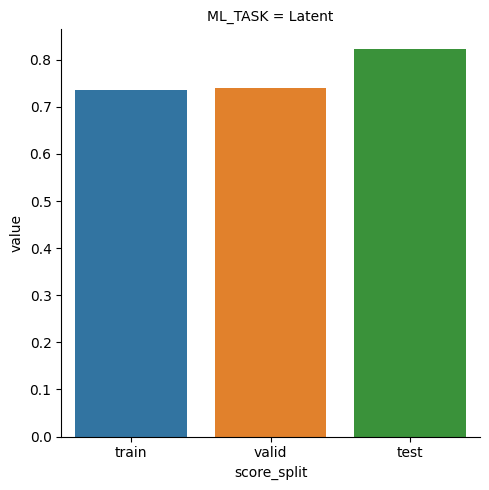

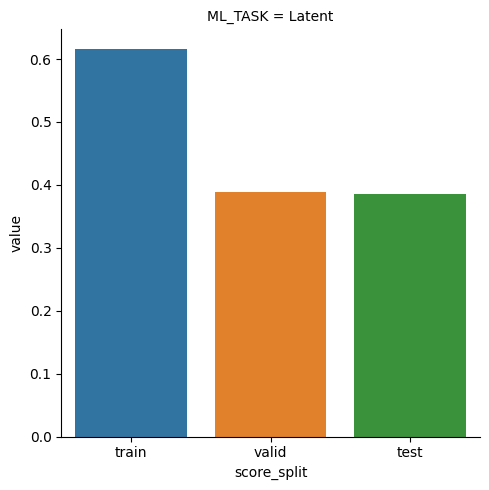

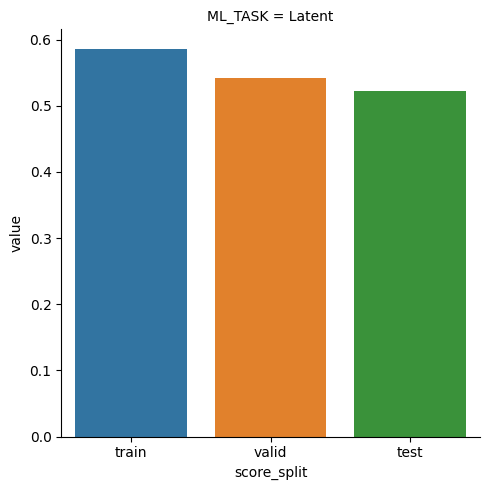

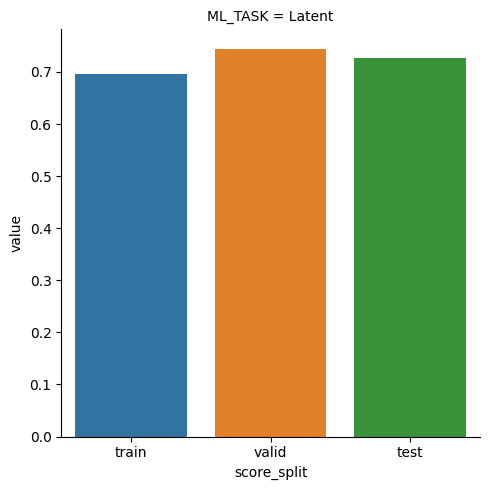

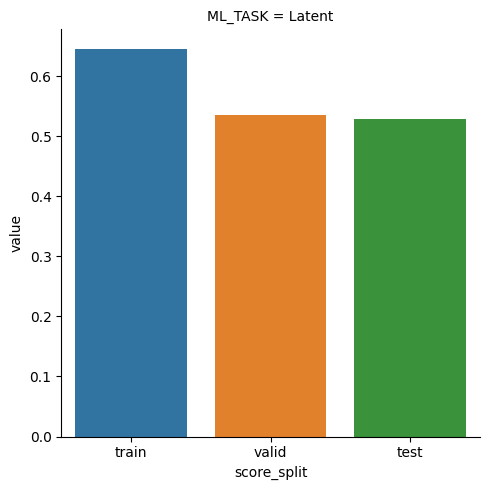

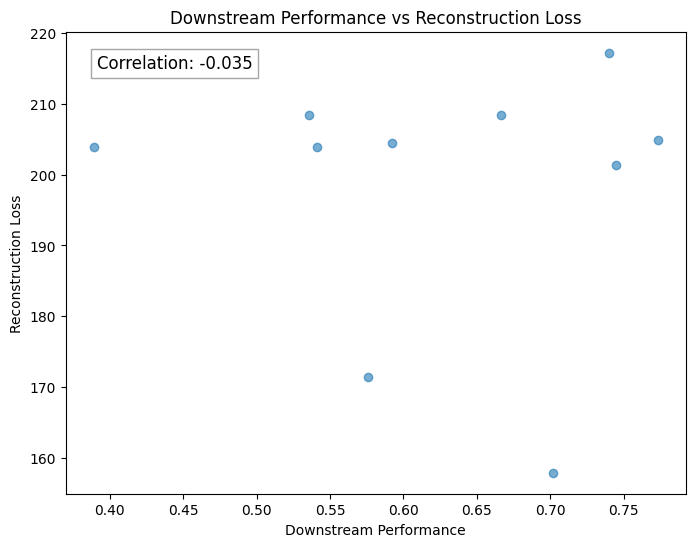

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from optuna.trial import TrialState

# Extract the metrics stored in user_attrs for all completed trials
completed_trials = [t for t in study.trials if t.state == TrialState.COMPLETE]

y = [t.user_attrs.get("reconstruction_loss") for t in completed_trials]
x = [t.user_attrs.get("downstream_performance") for t in completed_trials]

corr = np.corrcoef(x, y)[0, 1]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("Downstream Performance")
plt.ylabel("Reconstruction Loss")
plt.title("Downstream Performance vs Reconstruction Loss")
# plt.xlim(0.8, 1.0) ## Limit to good and very good runs
# plt.ylim(500, 600) ##

plt.text(
	0.05, 0.95,
	f"Correlation: {corr:.3f}",
	transform=plt.gca().transAxes,
	fontsize=12,
	verticalalignment='top',
	bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.show()



## Selecting and Saving the Best Configuration

After the optimization finishes, we can query the study for the best configuration.
This configuration can then be reused for final training or further experiments.
We can also save the entire study using standard python `pickle` or Optuna's relational database (RDB) backends.

---

In [13]:
print(f"Best objective value: {study.best_value}")
print(f"Best configuration found: {study.best_params}")

import pickle

with open("optuna_study.pkl", "wb") as f:
    pickle.dump(study, f)

print("Saved optuna_study.pkl")

with open("optuna_study.pkl", "rb") as f:
	loaded_study = pickle.load(f)
print("Loaded optuna_study.pkl")


Best objective value: 157.89654296875
Best configuration found: {'batch_size': 2479, 'drop_p': 0.04180537144799795, 'enc_factor': 4, 'weight_decay': 4.809461967501571e-05, 'beta': 2.4564592152507503e-05, 'learning_rate': 0.062451395747430666, 'n_layers': 5}
Saved optuna_study.pkl
Loaded optuna_study.pkl
